In [1]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

  IBM3201 — Sentiment Analysis: Amazon Fine Food Reviews
 All libraries imported successfully!

────────────────────────────────────────────────────────────
PHASE 1 — BUSINESS UNDERSTANDING
────────────────────────────────────────────────────────────
Goal     : Classify Amazon food reviews into 3 sentiment classes
Classes  : Negative (1-2 stars) | Neutral (3 stars) | Positive (4-5 stars)
Models   : Naive Bayes, Logistic Regression, SVM
Metric   : Weighted F1-Score (target >= 0.80)

────────────────────────────────────────────────────────────
PHASE 2 — DATA UNDERSTANDING
────────────────────────────────────────────────────────────
 Dataset loaded successfully!
   Shape            : (568454, 10)
   Columns          : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
   Missing values   :
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
Helpfu

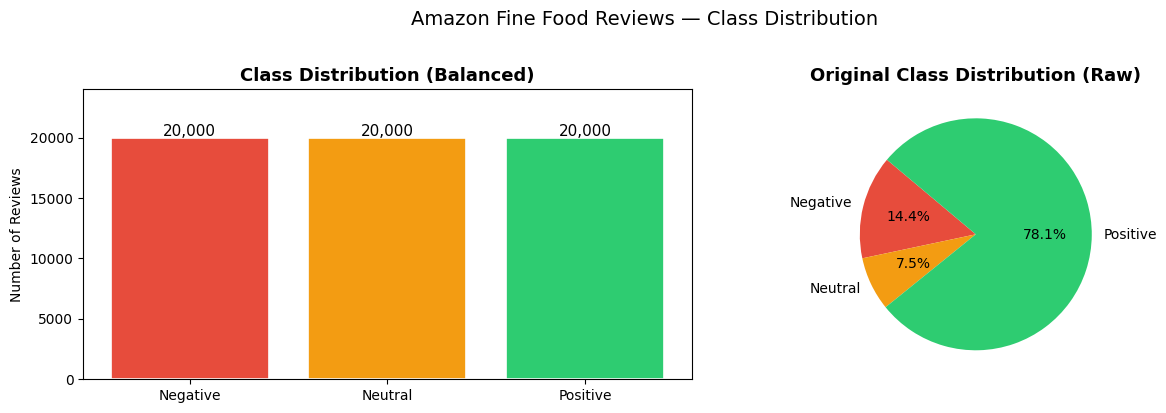

    Fig 1 saved: fig1_class_distribution.png


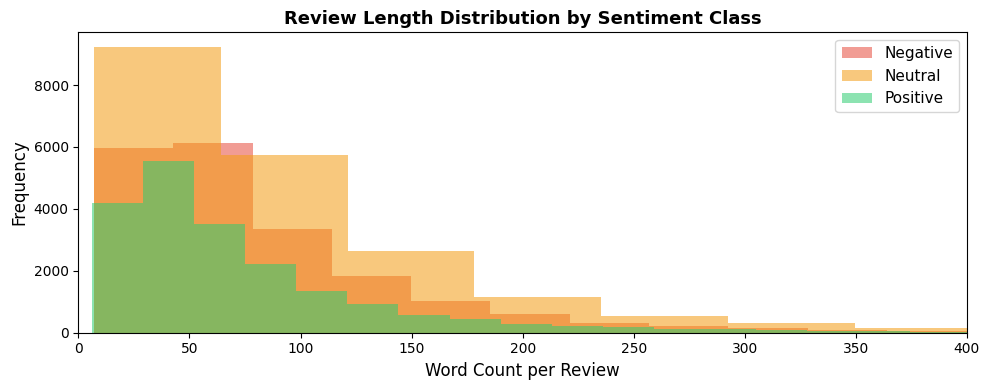

    Fig 2 saved: fig2_text_length.png

   Avg review length : 87.6 words
   Max review length : 3432 words
   Min review length : 6 words

────────────────────────────────────────────────────────────
PHASE 3 — DATA PREPARATION
────────────────────────────────────────────────────────────
Running preprocessing pipeline on 60,000 reviews...
 Preprocessing complete! Time: 37.4s

   BEFORE : I really wanted to love the product because it was the cheapest out of all the BLUE recipes (per pound) but her poo was sooooooo stinky using this.  We tried for 6 months and I thought we had just got

   AFTER  : really wanted love product cheapest blue recipe per pound poo sooooooo stinky using tried month thought gotten foul smelling kitten entire time vet said diet too rich switch tried blue longevity stink

 Generating text analysis visualisations...


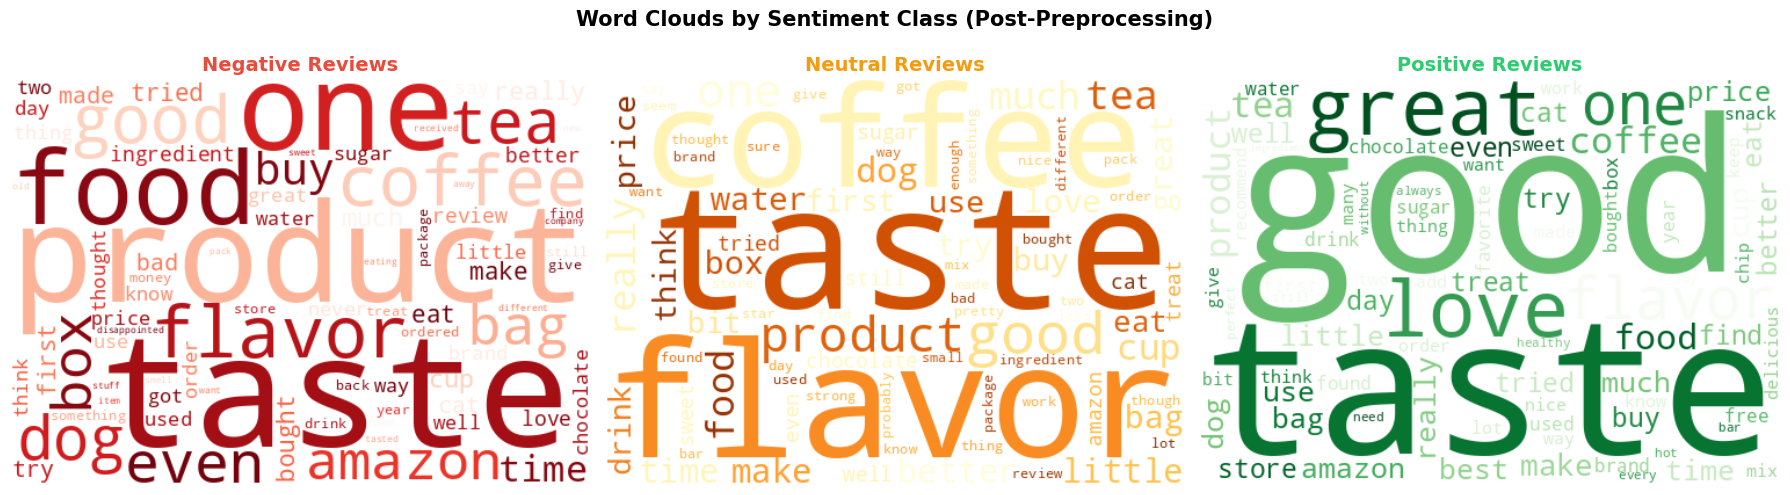

    Fig 3 saved: fig3_wordclouds.png


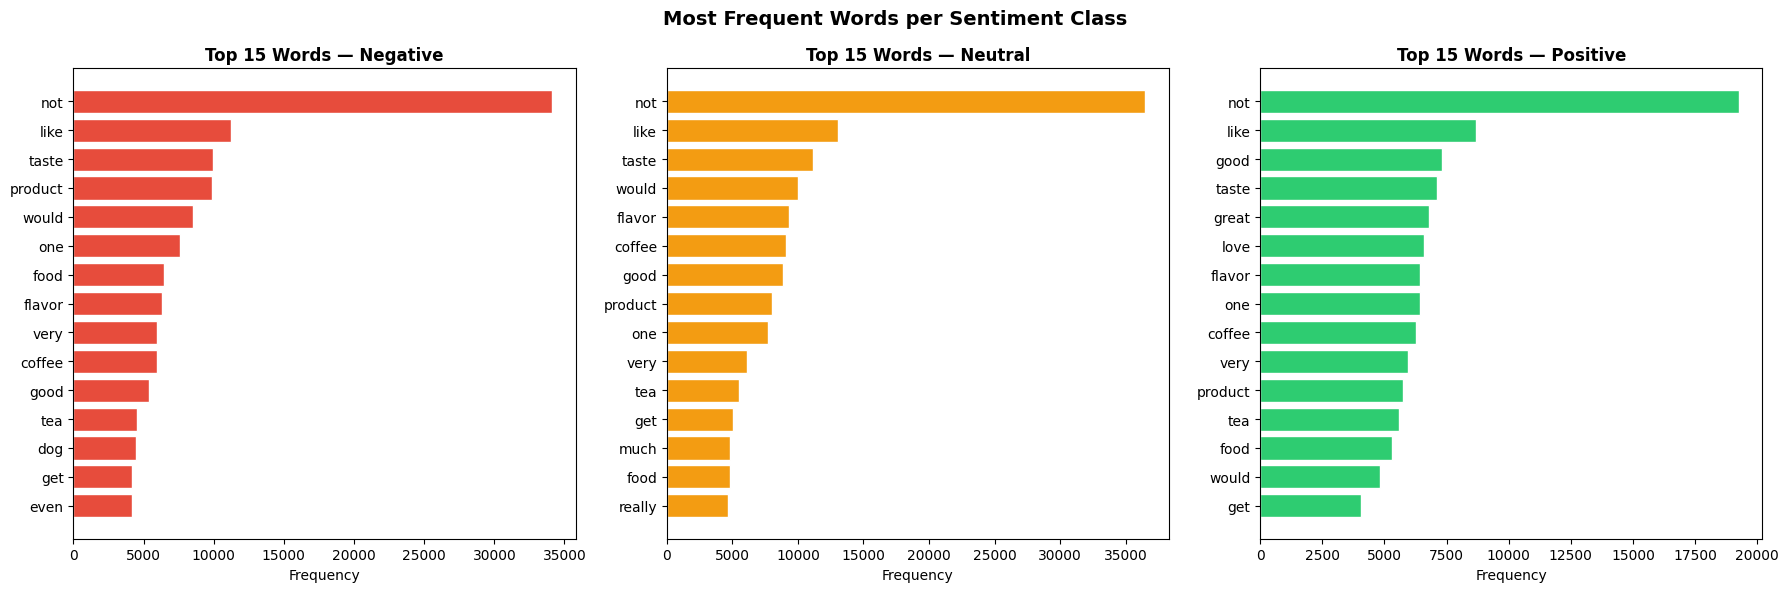

 Fig 4 saved: fig4_top_words.png

   Train set : 48,000 reviews (80%)
   Test set  : 12,000  reviews (20%)

   TF-IDF matrix (train) : (48000, 15000)
   TF-IDF matrix (test)  : (12000, 15000)
   Sample features       : ['ability', 'able', 'able buy', 'able drink', 'able eat', 'able enjoy', 'able find', 'able get', 'able make', 'able order', 'able use', 'absolute', 'absolute favorite', 'absolutely', 'absolutely awful']

────────────────────────────────────────────────────────────
PHASE 4 — MODELLING
────────────────────────────────────────────────────────────
 Hyperparameter Tuning with GridSearchCV (3-Fold CV)...
   Tuning: Naive Bayes
     Best params : {'alpha': 1.0}
     CV F1       : 0.7099  |  Time: 2.8s

   Tuning: Logistic Regression
     Best params : {'C': 5.0, 'max_iter': 1000}
     CV F1       : 0.7358  |  Time: 59.8s

   Tuning: Support Vector Machine
     Best params : {'C': 0.5}
     CV F1       : 0.7331  |  Time: 30.5s

 Hyperparameter tuning complete!

 Training final t

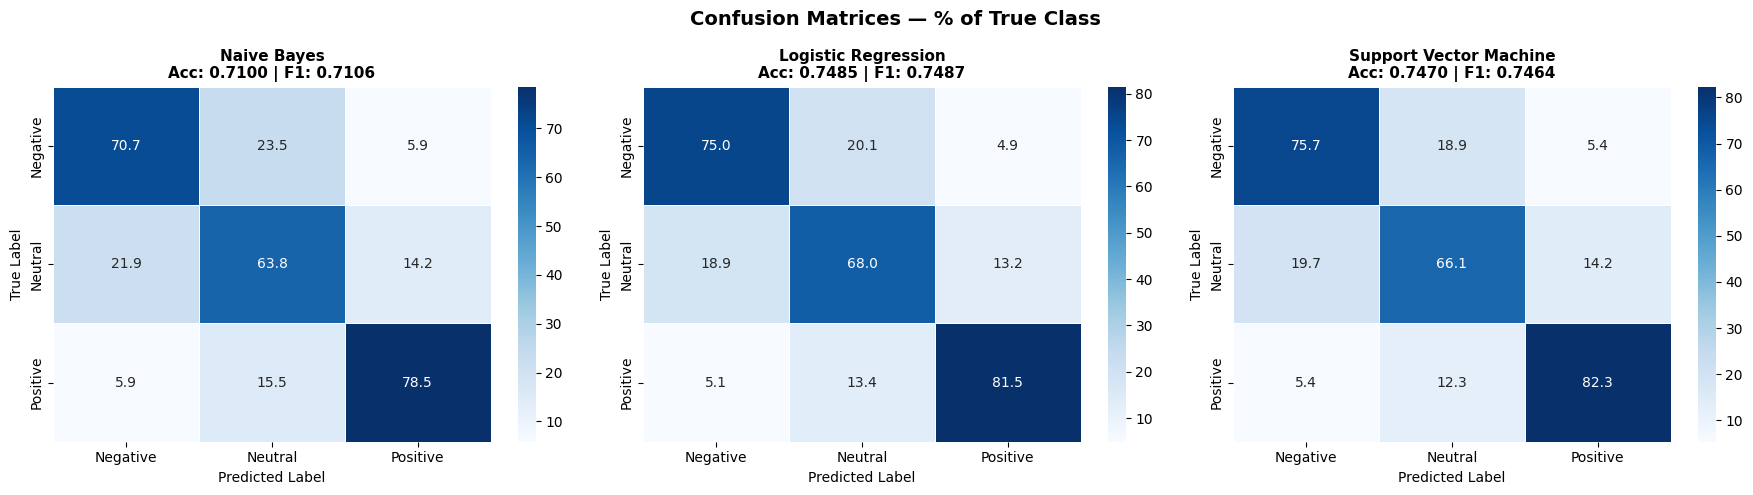

   Fig 5 saved: fig5_confusion_matrices.png


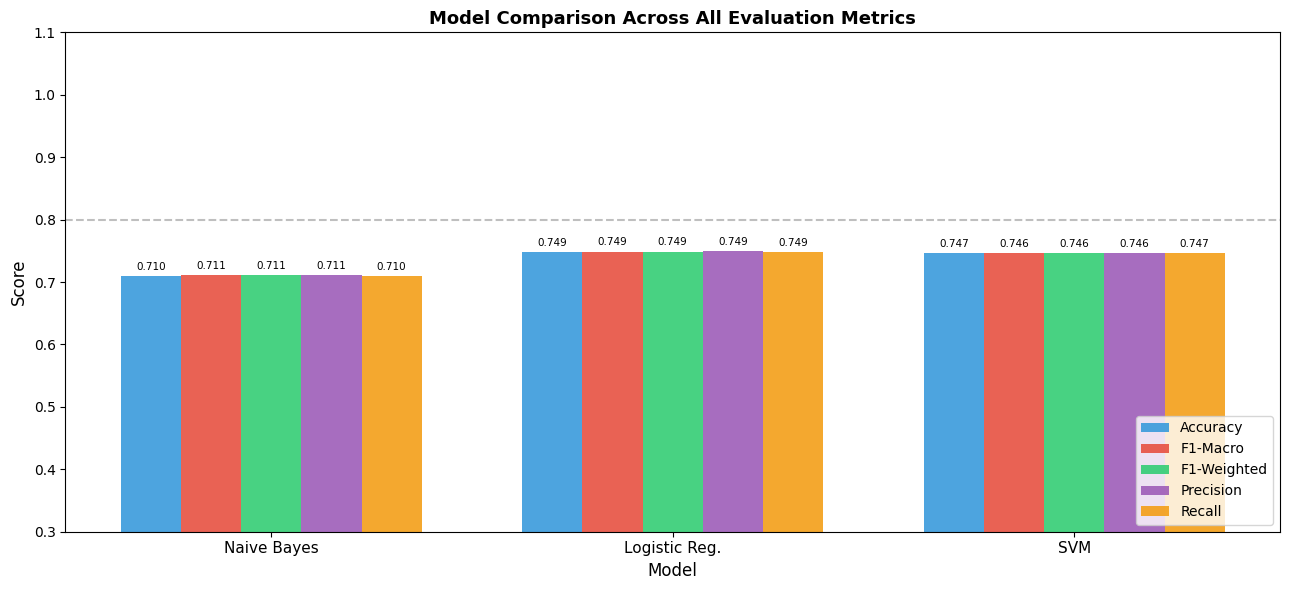

    Fig 6 saved: fig6_model_comparison.png


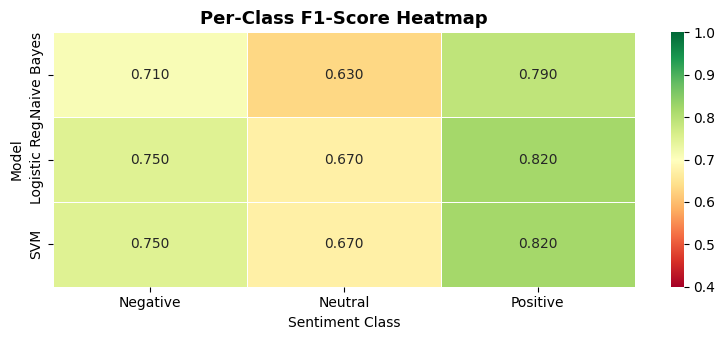

    Fig 7 saved: fig7_f1_heatmap.png


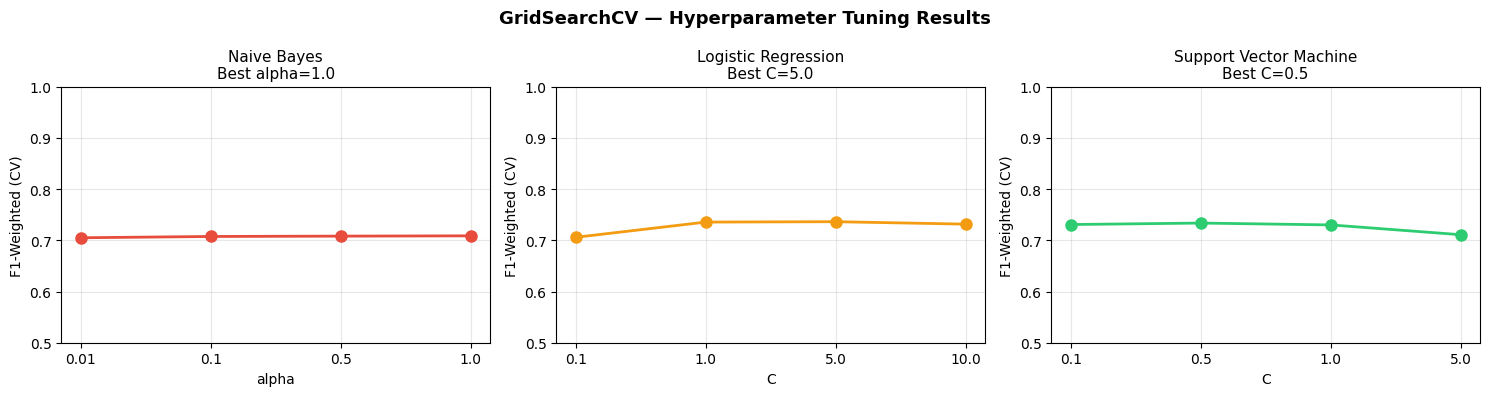

    Fig 8 saved: fig8_hyperparameter_tuning.png

────────────────────────────────────────────────────────────
PHASE 6 — DEPLOYMENT
────────────────────────────────────────────────────────────

 Sentiment Predictions using best model: Logistic Regression

────────────────────────────────────────────────────────────
Review   : This is absolutely the best granola I have ever tasted. Will buy again!...
Verdict  : 😊 Positive

Review   : Product arrived on time but the taste is just okay. Nothing special....
Verdict  : 😐 Neutral

Review   : Complete waste of money. Tastes awful and packaging was damaged....
Verdict  :  😞 Negative

Review   : Not bad for the price. I expected better flavour but it does the job....
Verdict  : 😐 Neutral

Review   : My dog loves these treats! She goes crazy every time I open the bag....
Verdict  : 😊 Positive

Review   : Disgusting smell, terrible aftertaste. Do not buy this product....
Verdict  :  😞 Negative

Model and vectorizer saved successfully!
  FINAL SUMM

In [7]:

#         IBM3201 /  DATA MINING & PREDICTIVE ANALYTICS
#                     COURSEWORK #3 - ASSIGNMENT (40%)

#  Title      : Sentiment Analysis of Amazon Fine Food Reviews
#  Dataset    : Amazon Fine Food Reviews (568,454 reviews)
#  Task       : 3-Class Sentiment Classification
#               (Negative / Neutral / Positive)
#  Algorithms : 1. Naive Bayes (Multinomial)
#               2. Logistic Regression
#               3. Support Vector Machine (LinearSVC)
#  Methodology: CRISP-DM (6 Phases)
#  Language   : Python 3




#  INSTALL & IMPORT LIBRARIE

!pip install nltk wordcloud matplotlib seaborn scikit-learn pandas numpy

import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from sklearn.utils import resample
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Download NLTK resources
for resource in ['stopwords', 'wordnet', 'punkt', 'omw-1.4',
                 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

print("=" * 60)
print("  IBM3201 — Sentiment Analysis: Amazon Fine Food Reviews")
print("=" * 60)
print(" All libraries imported successfully!\n")


#  PHASE 1 — BUSINESS UNDERSTANDING  (CRISP-DM Step 1)

# OBJECTIVE:
#   Businesses selling products on Amazon need to understand
#   customer feedback at scale. Manual review reading is
#   impractical with millions of reviews. This project builds
#   an automated NLP pipeline to classify customer reviews as
#   Negative, Neutral, or Positive — enabling:
#     • Product quality monitoring
#     • Customer satisfaction tracking
#     • Automated feedback routing
#
# PROBLEM TYPE  : Multi-class text classification
# TARGET CLASSES: 0=Negative, 1=Neutral, 2=Positive
# SUCCESS METRIC: Weighted F1-Score >= 0.80


print("─" * 60)
print("PHASE 1 — BUSINESS UNDERSTANDING")
print("─" * 60)
print("Goal     : Classify Amazon food reviews into 3 sentiment classes")
print("Classes  : Negative (1-2 stars) | Neutral (3 stars) | Positive (4-5 stars)")
print("Models   : Naive Bayes, Logistic Regression, SVM")
print("Metric   : Weighted F1-Score (target >= 0.80)\n")



#  PHASE 2 — DATA UNDERSTANDING  (CRISP-DM Step 2)


print("─" * 60)
print("PHASE 2 — DATA UNDERSTANDING")
print("─" * 60)

# 2.1  Load Dataset
df_raw = pd.read_csv('/content/drive/MyDrive/amazon data set.csv')

print(f" Dataset loaded successfully!")
print(f"   Shape            : {df_raw.shape}")
print(f"   Columns          : {df_raw.columns.tolist()}")
print(f"   Missing values   :\n{df_raw.isnull().sum()}\n")

# Keep only relevant columns
df = df_raw[['Score', 'Text']].dropna().copy()
df.columns = ['score', 'text']

print(f"   Reviews after removing nulls : {len(df):,}")
print(f"\n   Star Rating Distribution:")
print(df['score'].value_counts().sort_index().to_string())

# 2.2  Map Ratings → Sentiment Labels
# Justification:
#   1-2 stars → Negative  : Customer dissatisfied
#   3   stars → Neutral   : Mixed / indifferent opinion
#   4-5 stars → Positive  : Customer satisfied

def map_sentiment(score):
    if score <= 2:   return 0   # Negative
    elif score == 3: return 1   # Neutral
    else:            return 2   # Positive

df['label'] = df['score'].apply(map_sentiment)
LABEL_NAMES  = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
CLASS_COLORS = {0: '#e74c3c',  1: '#f39c12', 2: '#2ecc71'}

print(f"\n   Raw Sentiment Distribution:")
for label, name in LABEL_NAMES.items():
    count = (df['label'] == label).sum()
    pct   = count / len(df) * 100
    print(f"   {name:10} : {count:>7,}  ({pct:.1f}%)")

#  2.3  Balance Dataset
# The dataset is heavily skewed toward positive reviews.
# We balance to 20,000 per class to prevent model bias.

N_PER_CLASS = 20000

balanced_parts = []
for label in [0, 1, 2]:
    subset = df[df['label'] == label]
    balanced_parts.append(
        resample(subset,
                 replace=len(subset) < N_PER_CLASS,
                 n_samples=N_PER_CLASS,
                 random_state=42)
    )

df_bal = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

texts  = df_bal['text'].tolist()
labels = df_bal['label'].tolist()

print(f"\n   Balanced dataset : {len(df_bal):,} reviews ({N_PER_CLASS:,} per class)")

#  2.4  EDA Visualisations
print("\n Generating EDA visualisations...")

#  Fig 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = [labels.count(i) for i in range(3)]
bars = axes[0].bar([LABEL_NAMES[i] for i in range(3)], counts,
                   color=[CLASS_COLORS[i] for i in range(3)],
                   edgecolor='white', linewidth=1.2)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{count:,}', ha='center', fontsize=11)
axes[0].set_title('Class Distribution (Balanced)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, N_PER_CLASS * 1.2)

# Raw distribution pie
raw_counts = [df['label'].value_counts().get(i, 0) for i in range(3)]
axes[1].pie(raw_counts,
            labels=[LABEL_NAMES[i] for i in range(3)],
            colors=[CLASS_COLORS[i] for i in range(3)],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Original Class Distribution (Raw)', fontsize=13, fontweight='bold')

plt.suptitle('Amazon Fine Food Reviews — Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 1 saved: fig1_class_distribution.png")

#  Fig 2: Review Length Distribution
lengths = [len(str(t).split()) for t in texts]
df_eda  = pd.DataFrame({'length': lengths, 'label': labels})

plt.figure(figsize=(10, 4))
for label, name in LABEL_NAMES.items():
    subset = df_eda[df_eda['label'] == label]['length']
    plt.hist(subset, bins=60, alpha=0.55,
             color=CLASS_COLORS[label], label=name)
plt.xlabel('Word Count per Review', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Review Length Distribution by Sentiment Class', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.xlim(0, 400)
plt.tight_layout()
plt.savefig('fig2_text_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 2 saved: fig2_text_length.png")

print(f"\n   Avg review length : {np.mean(lengths):.1f} words")
print(f"   Max review length : {np.max(lengths)} words")
print(f"   Min review length : {np.min(lengths)} words")


#  PHASE 3 — DATA PREPARATION  (CRISP-DM Step 3)


print("\n" + "─" * 60)
print("PHASE 3 — DATA PREPARATION")
print("─" * 60)

#  3.1  NLP Preprocessing Pipeline

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Keep negation words — critical for sentiment (e.g. "not good")
negations = {
    'no', 'not', 'nor', 'neither', 'never', 'nobody', 'nothing',
    'nowhere', 'cannot', "don't", "won't", "isn't", "aren't",
    "wasn't", "weren't", "hasn't", "haven't", "didn't", "doesn't",
    "wouldn't", "couldn't", "shouldn't", "very", "too"
}
stop_words = stop_words - negations

CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re"  : " are",    "'s"   : " is",    "'d" : " would",
    "'ll"  : " will",   "'ve"  : " have",  "'m" : " am"
}

def preprocess_text(text):
    """
    NLP Preprocessing Pipeline
    Step 1 : Remove HTML tags
    Step 2 : Remove URLs and email addresses
    Step 3 : Expand contractions (e.g. don't → do not)
    Step 4 : Remove special characters and numbers
    Step 5 : Convert to lowercase
    Step 6 : Tokenize (word-level)
    Step 7 : Remove stopwords (negations preserved)
    Step 8 : Lemmatize tokens to dictionary base form

    Parameters : text (str) — raw review text
    Returns    : cleaned (str) — preprocessed text
    """
    text = str(text)

    # Step 1: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 2: Remove URLs and emails
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Step 3: Expand contractions
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)

    # Step 4: Remove special characters, punctuation, numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Step 5: Lowercase
    text = text.lower()

    # Step 6: Tokenize
    tokens = word_tokenize(text)

    # Step 7: Remove stopwords and very short tokens (≤2 chars)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Step 8: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


print("Running preprocessing pipeline on 60,000 reviews...")

start_time    = time.time()
cleaned_texts = [preprocess_text(t) for t in texts]
elapsed       = time.time() - start_time

print(f" Preprocessing complete! Time: {elapsed:.1f}s")
print(f"\n   BEFORE : {texts[0][:200]}")
print(f"\n   AFTER  : {cleaned_texts[0][:200]}")

# 3.2  EDA on Cleaned Text
print("\n Generating text analysis visualisations...")

#  Fig 3: Word Clouds (3 classes)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Reds', 'YlOrBr', 'Greens']

for i, (label, name) in enumerate(LABEL_NAMES.items()):
    class_text = ' '.join(
        [t for t, l in zip(cleaned_texts, labels) if l == label]
    )
    wc = WordCloud(width=500, height=350,
                   background_color='white',
                   colormap=cmaps[i],
                   max_words=80,
                   collocations=False).generate(class_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{name} Reviews', fontsize=14, fontweight='bold',
                      color=CLASS_COLORS[label])
    axes[i].axis('off')

plt.suptitle('Word Clouds by Sentiment Class (Post-Preprocessing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 3 saved: fig3_wordclouds.png")

#  Fig 4: Top 15 Words Per Class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (label, name) in enumerate(LABEL_NAMES.items()):
    class_text = ' '.join(
        [t for t, l in zip(cleaned_texts, labels) if l == label]
    )
    freq  = Counter(class_text.split()).most_common(15)
    words = [w for w, _ in freq]
    counts= [c for _, c in freq]

    axes[i].barh(words, counts, color=CLASS_COLORS[label], edgecolor='white')
    axes[i].set_title(f'Top 15 Words — {name}', fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Fig 4 saved: fig4_top_words.png")

#  3.3  Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_texts, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels          # preserve class ratios in both splits
)

print(f"\n   Train set : {len(X_train):,} reviews (80%)")
print(f"   Test set  : {len(X_test):,}  reviews (20%)")

# 3.4  TF-IDF Feature Extraction
# Justification:
#   • ngram_range=(1,2) : Captures unigrams AND bigrams
#     (e.g. "not good", "highly recommend" carry sentiment)
#   • sublinear_tf=True : Applies log(1+tf) to reduce dominance
#     of very frequent terms
#   • max_features=15000: Keeps top 15k features — balance
#     between expressiveness and computational efficiency
#   • min_df=3          : Ignore rare terms (noise reduction)
#   • max_df=0.90       : Ignore near-universal terms

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.90
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\n   TF-IDF matrix (train) : {X_train_tfidf.shape}")
print(f"   TF-IDF matrix (test)  : {X_test_tfidf.shape}")
print(f"   Sample features       : {tfidf.get_feature_names_out()[:15].tolist()}")

#  PHASE 4 — MODELLING  (CRISP-DM Step 4)

print("\n" + "─" * 60)
print("PHASE 4 — MODELLING")
print("─" * 60)

# 4.1  Define Base Models
#
# Model 1: Multinomial Naive Bayes
#   - Probabilistic classifier based on Bayes' theorem
#   - Works well with TF-IDF sparse matrices
#   - Fast training, good baseline for text classification
#
# Model 2: Logistic Regression
#   - Linear classifier optimised with multinomial log-loss
#   - Handles high-dimensional sparse text features well
#   - Provides probability estimates per class
#
# Model 3: Support Vector Machine (LinearSVC)
#   - Finds optimal hyperplane maximising margin between classes
#   - Excellent for high-dimensional text data
#   - Strong performance on NLP classification tasks

base_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        multi_class='multinomial', solver='lbfgs',
        max_iter=1000, random_state=42
    ),
    "Support Vector Machine": LinearSVC(
        max_iter=3000, random_state=42
    )
}

# 4.2  Hyperparameter Tuning — GridSearchCV
# GridSearchCV exhaustively searches over a parameter grid
# using Stratified K-Fold cross-validation (k=3) to prevent
# data leakage and ensure fair evaluation on unseen folds.

print(" Hyperparameter Tuning with GridSearchCV (3-Fold CV)...")


param_grids = {
    "Naive Bayes": {
        'alpha': [0.01, 0.1, 0.5, 1.0]
    },
    "Logistic Regression": {
        'C'       : [0.1, 1.0, 5.0, 10.0],
        'max_iter': [1000]
    },
    "Support Vector Machine": {
        'C': [0.1, 0.5, 1.0, 5.0]
    }
}

cv_strategy  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tuned_models = {}

for name, model in base_models.items():
    print(f"   Tuning: {name}")
    t0 = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1_weighted',
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_tfidf, y_train)

    best_model  = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    elapsed     = time.time() - t0

    tuned_models[name] = {
        'model'      : best_model,
        'best_params': best_params,
        'cv_score'   : best_score
    }

    print(f"     Best params : {best_params}")
    print(f"     CV F1       : {best_score:.4f}  |  Time: {elapsed:.1f}s\n")

print(" Hyperparameter tuning complete!")

# 4.3  Train Tuned Models & Predict
results = {}

print("\n Training final tuned models on full training set...\n")

for name, info in tuned_models.items():
    model  = info['model']
    y_pred = model.predict(X_test_tfidf)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wt   = f1_score(y_test, y_pred, average='weighted')
    prec    = precision_score(y_test, y_pred, average='weighted')
    rec     = recall_score(y_test, y_pred, average='weighted')
    report  = classification_report(
                  y_test, y_pred,
                  target_names=['Negative', 'Neutral', 'Positive']
              )
    cm      = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model'      : model,
        'best_params': info['best_params'],
        'cv_score'   : info['cv_score'],
        'y_pred'     : y_pred,
        'accuracy'   : acc,
        'f1_macro'   : f1_mac,
        'f1_weighted': f1_wt,
        'precision'  : prec,
        'recall'     : rec,
        'report'     : report,
        'cm'         : cm
    }

    print(f"   {name}")
    print(f"     Accuracy     : {acc:.4f}")
    print(f"     F1-Macro     : {f1_mac:.4f}")
    print(f"     F1-Weighted  : {f1_wt:.4f}")
    print(f"     Precision    : {prec:.4f}")
    print(f"     Recall       : {rec:.4f}\n")


#  PHASE 5 — EVALUATION  (CRISP-DM Step 5)

print("─" * 60)
print("PHASE 5 — EVALUATION")
print("─" * 60)

#  5.1  Summary Comparison Table
print("\n" + "=" * 72)
print("                    MODEL COMPARISON SUMMARY")
print("=" * 72)
print(f"{'Model':<28} {'Accuracy':>9} {'F1-Mac':>8} {'F1-Wt':>8} "
      f"{'Prec':>8} {'Recall':>8}")
print("-" * 72)
for name, r in results.items():
    print(f"{name:<28} {r['accuracy']:>9.4f} {r['f1_macro']:>8.4f} "
          f"{r['f1_weighted']:>8.4f} {r['precision']:>8.4f} {r['recall']:>8.4f}")
print("=" * 72)

# Best model
best_name = max(results, key=lambda n: results[n]['f1_weighted'])
print(f"\n Best Model: {best_name}  "
      f"(F1-Weighted = {results[best_name]['f1_weighted']:.4f})")

#  5.2  Detailed Classification Report
print(f"\nDetailed Classification Report — {best_name}:")
print(results[best_name]['report'])

#  5.3  Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
CLASS_LABELS = ['Negative', 'Neutral', 'Positive']

for ax, (name, r) in zip(axes, results.items()):
    cm_pct = (r['cm'].astype('float') /
               r['cm'].sum(axis=1)[:, np.newaxis] * 100)
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_LABELS,
                yticklabels=CLASS_LABELS, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{name}\nAcc: {r["accuracy"]:.4f} | F1: {r["f1_weighted"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices — % of True Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Fig 5 saved: fig5_confusion_matrices.png")

#  5.4  Model Comparison Bar Chart
model_names = list(results.keys())
metrics     = {
    'Accuracy'    : [results[n]['accuracy']    for n in model_names],
    'F1-Macro'    : [results[n]['f1_macro']    for n in model_names],
    'F1-Weighted' : [results[n]['f1_weighted'] for n in model_names],
    'Precision'   : [results[n]['precision']   for n in model_names],
    'Recall'      : [results[n]['recall']      for n in model_names],
}

x      = np.arange(len(model_names))
width  = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, vals) in enumerate(metrics.items()):
    offset = (i - len(metrics)/2) * width + width/2
    bars   = ax.bar(x + offset, vals, width,
                    label=metric, color=colors[i], alpha=0.88)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2,
                        bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison Across All Evaluation Metrics',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Naive Bayes', 'Logistic Reg.', 'SVM'], fontsize=11)
ax.set_ylim(0.3, 1.10)
ax.legend(fontsize=10, loc='lower right')
ax.axhline(y=0.80, color='grey', linestyle='--',
           alpha=0.5, label='Target (0.80)')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 6 saved: fig6_model_comparison.png")

#  5.5  Per-Class F1-Score Heatmap
heatmap_data = []

for name in model_names:
    row    = {}
    lines  = results[name]['report'].split('\n')
    for line in lines[2:5]:
        parts = line.split()
        if len(parts) >= 4:
            row[parts[0]] = float(parts[3])
    heatmap_data.append([
        row.get('Negative', 0),
        row.get('Neutral',  0),
        row.get('Positive', 0)
    ])

hm_df = pd.DataFrame(
    heatmap_data,
    index=['Naive Bayes', 'Logistic Reg.', 'SVM'],
    columns=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(8, 3.5))
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, linewidths=0.5, linecolor='white')
plt.title('Per-Class F1-Score Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig('fig7_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 7 saved: fig7_f1_heatmap.png")

#  5.6  Hyperparameter Tuning Results Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    param_name  = list(param_grids[name].keys())[0]
    param_vals  = param_grids[name][param_name]
    mean_scores = []

    for val in param_vals:
        params = {param_name: val}
        if name == "Logistic Regression":
            params['max_iter'] = 1000
        temp_model = base_models[name].__class__(**params)
        scores = cross_val_score(
            temp_model, X_train_tfidf, y_train,
            cv=3, scoring='f1_weighted', n_jobs=-1
        )
        mean_scores.append(scores.mean())

    ax.plot([str(v) for v in param_vals], mean_scores,
            marker='o', color=list(CLASS_COLORS.values())[
                list(results.keys()).index(name)],
            linewidth=2, markersize=8)
    ax.set_title(f'{name}\nBest {param_name}='
                 f'{r["best_params"][param_name]}', fontsize=11)
    ax.set_xlabel(param_name)
    ax.set_ylabel('F1-Weighted (CV)')
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3)

plt.suptitle('GridSearchCV — Hyperparameter Tuning Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Fig 8 saved: fig8_hyperparameter_tuning.png")

#  PHASE 6  DEPLOYMENT  (CRISP-DM Step 6)


print("\n" + "─" * 60)
print("PHASE 6 — DEPLOYMENT")
print("─" * 60)

def predict_sentiment(text, model_name=None):
    """
    Predict 3-class sentiment for any input text.

    Parameters : text       (str) — raw review text
                 model_name (str) — model to use (default: best model)
    Returns    : dict with label, class name, and confidence note
    """
    if model_name is None:
        model_name = best_name

    cleaned  = preprocess_text(text)
    vec      = tfidf.transform([cleaned])
    pred     = results[model_name]['model'].predict(vec)[0]

    emoji_map = {0: " 😞 Negative", 1: "😐 Neutral", 2: "😊 Positive"}
    return {
        'sentiment'   : emoji_map[pred],
        'label'       : int(pred),
        'model_used'  : model_name,
        'cleaned_text': cleaned
    }

# Demo predictions
test_reviews = [
    "This is absolutely the best granola I have ever tasted. Will buy again!",
    "Product arrived on time but the taste is just okay. Nothing special.",
    "Complete waste of money. Tastes awful and packaging was damaged.",
    "Not bad for the price. I expected better flavour but it does the job.",
    "My dog loves these treats! She goes crazy every time I open the bag.",
    "Disgusting smell, terrible aftertaste. Do not buy this product.",
]

print(f"\n Sentiment Predictions using best model: {best_name}\n")
print("─" * 60)

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"Review   : {review[:75]}...")
    print(f"Verdict  : {result['sentiment']}")
    print()
# Save best model
pickle.dump(
    results[best_name]['model'],
    open("logistic_regression_model.pkl", "wb")
)

# Save TF-IDF vectorizer
pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl", "wb")
)

print("Model and vectorizer saved successfully!")

# Final Summary
print("=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset    : Amazon Fine Food Reviews")
print(f"  Task       : 3-Class Sentiment Analysis")
print(f"  Total docs : {len(cleaned_texts):,}")
print(f"  Features   : TF-IDF (unigrams + bigrams, 15k features)")
print()
for name, r in results.items():
    marker = " ← BEST" if name == best_name else ""
    print(f"  {name:<28} F1={r['f1_weighted']:.4f}{marker}")

print()
print("  Charts saved:")
charts = [
    "fig1_class_distribution.png",
    "fig2_text_length.png",
    "fig3_wordclouds.png",
    "fig4_top_words.png",
    "fig5_confusion_matrices.png",
    "fig6_model_comparison.png",
    "fig7_f1_heatmap.png",
    "fig8_hyperparameter_tuning.png",
]
for c in charts:
    print(f"     {c}")

print()

